# A (mock-up of a) demo notebook for threshold-based analysis

In [1]:
!pip install git+https://github.com/OpenHydrology/lmoments3.git

  Cloning https://github.com/OpenHydrology/lmoments3.git to /tmp/pip-req-build-refa0x42
  Running command git clone -q https://github.com/OpenHydrology/lmoments3.git /tmp/pip-req-build-refa0x42


In [5]:
# import packages

import requests 
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

import lmoments3 as lm
from lmoments3 import distr

import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# import cal-adapt analytics engine package
import cae_package as ck 

## 1. Select

### Choose a location, variables, scenarios, and designate warming levels of interest:

In [6]:
ck.select()

Column
    [0] Row
        [0] Column(margin=5, name='DataSelector', width=300)
            [0] StaticText(value='<b>DataSelector</b>')
            [1] Select(name='Cached station', options=OrderedDict([('', ...]))
            [2] Select(name='Timescale', options=OrderedDict([('hourly', ...]), value='hourly')
            [3] Select(name='Variable', options=OrderedDict([('2-m tempera...]), value='2-m temperature')
        [1] CheckBoxGroup(name='Dynamical/Statistical', options=['Dynamical', ...])
    [1] Row
        [0] CheckBoxGroup(name='Warming Levels', options=['2˚', '3˚', '4˚'])
        [1] CheckBoxGroup(name='Scenarios', options=["Historical -- What's Alr...])

## 2. Generate

### Generate data array based on selections 

In [7]:
da = ck.generate()
da

<xarray.DataArray 'tas' (time: 1872, lat: 96, lon: 144)>
array([[[-26.09562  , -25.560062 , -24.417953 , ..., -25.568878 ,
         -26.768753 , -26.853813 ],
        [-21.15298  , -22.623005 , -22.773903 , ..., -20.67329  ,
         -21.146774 , -22.306519 ],
        [-16.14066  , -16.60736  , -17.41631  , ..., -16.316113 ,
         -15.296085 , -16.233467 ],
        ...,
        [-27.338696 , -27.701656 , -27.880844 , ..., -26.580338 ,
         -26.776058 , -27.004242 ],
        [-30.437195 , -30.610699 , -30.783459 , ..., -30.11428  ,
         -30.204533 , -30.307201 ],
        [-32.727737 , -32.707    , -32.70571  , ..., -32.784454 ,
         -32.76465  , -32.7555   ]],

       [[-43.910034 , -43.514114 , -41.942764 , ..., -43.587997 ,
         -44.180656 , -44.330452 ],
        [-39.7862   , -41.305557 , -41.638634 , ..., -39.258064 ,
         -39.746185 , -40.903847 ],
        [-33.62661  , -34.050926 , -34.82937  , ..., -33.32067  ,
         -32.76641  , -33.57904  ],
...
        [-23.33363  , -23.123516 , -22.956139 , ..., -23.934086 ,
         -23.751549 , -23.567226 ],
        [-22.787445 , -22.759842 , -22.711666 , ..., -22.804611 ,
         -22.800629 , -22.794476 ],
        [-22.835892 , -22.820404 , -22.812904 , ..., -22.944    ,
         -22.89618  , -22.85891  ]],

       [[-23.020271 , -23.019089 , -22.851685 , ..., -22.828175 ,
         -23.082703 , -22.965942 ],
        [-21.113266 , -20.822071 , -21.645111 , ..., -20.474628 ,
         -20.79359  , -20.83891  ],
        [-14.783768 , -15.698982 , -15.880283 , ..., -13.559807 ,
         -14.224342 , -14.645584 ],
        ...,
        [-15.215282 , -14.894455 , -14.627293 , ..., -16.329407 ,
         -15.996273 , -15.620514 ],
        [-16.874847 , -16.745651 , -16.622135 , ..., -17.245804 ,
         -17.125061 , -17.001274 ],
        [-19.763016 , -19.771038 , -19.781311 , ..., -19.870956 ,
         -19.811138 , -19.774033 ]]], dtype=float32)
Coordinates:
  * time     (time) object 1850-01-16 12:00:00 ... 2005-12-16 12:00:00
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 ...
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    units:             F
    original_name:     TREFHT
    cell_methods:      time: mean
    cell_measures:     area: areacella
    history:           2011-06-01T03:52:41Z altered by CMOR: Treated scalar d...
    associated_files:  baseURL: http://cmip-pcmdi.llnl.gov/CMIP5/dataLocation...

## 3. Transform (by Return Period)

### Transform data according to return period

In [8]:
ck.setReturnPeriod()

Column
    [0] Column(margin=5, name='ThresholdSelector', width=300)
        [0] StaticText(value='<b>ThresholdSelector</b>'...)
        [1] Select(name='Distributions', options=OrderedDict([('Exponential...]), value='Exponential')
    [1] RadioButtonGroup(name='New Temporal Resolution', options=['annual'], value='annual')
    [2] RadioButtonGroup(name='Return Period(s)', options=['2 years', '5 years', ...], value='2 years')
    [3] Row
        [0] IntRangeSlider(end=2015, name='Reference Period Years', start=1850, value=(1850, 2015), value_end=2015, value_start=1850)

## 4. Calculate

### Calculate return values based on selected transformations

In [9]:
# stack points in data array to prepare for calculations

da_stacked = da.stack(allpoints=['lon','lat']).squeeze()
da_stacked = da_stacked.groupby('allpoints')

In [11]:
return_values = da_stacked.apply(ck.getReturnValue)

In [12]:
# unstack points in return value data array

return_values = return_values.unstack('allpoints').transpose()

## 5. Visualize

### Visualize calculated return values across Western US

/srv/conda/envs/notebook/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1797: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = matplotlib.axes.Axes.pcolormesh(self, *args, **kwargs)


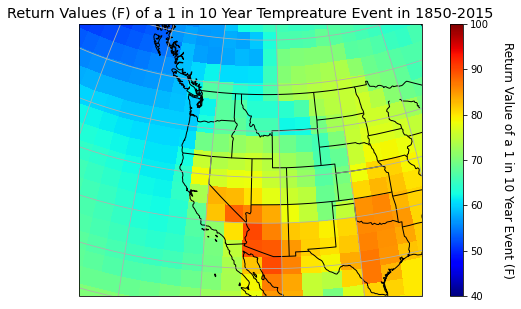

In [13]:
ck.getReturnValuePlot(return_values)

# Now let's calculate using a threshold value

## 3. Transform (by Threshold)

### Transform data according to a threshold

In [14]:
ck.setThreshold()

Column
    [0] Column(margin=5, name='ThresholdSelector', width=300)
        [0] StaticText(value='<b>ThresholdSelector</b>'...)
        [1] Select(name='Distributions', options=OrderedDict([('Exponential...]), value='Exponential')
    [1] RadioButtonGroup(name='New Temporal Resolution', options=['annual'], value='annual')
    [2] IntSlider(end=120, name='Threshold (Degrees F)', value=100)
    [3] Row
        [0] IntRangeSlider(end=2015, name='Reference Period Years', start=1850, value=(1850, 2015), value_end=2015, value_start=1850)

## 4. Calculate

### exceedance probabilities based on selected transformations

In [15]:
exceedances = da_stacked.apply(ck.getExceedance)

In [16]:
# unstack points in exceedances data array

exceedances = exceedances.unstack('allpoints').transpose()

## 5. Visualize

### Visualize calculated exceedance probabilities across Western US

/srv/conda/envs/notebook/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1797: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = matplotlib.axes.Axes.pcolormesh(self, *args, **kwargs)


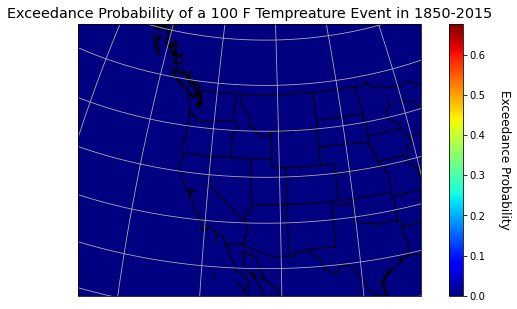

In [17]:
ck.getExceedancePlot(exceedances)

## 5. Export

### Download processed data

In [18]:
ck.export()

Column
    [0] Column(margin=5, name='ExportSelector', width=300)
        [0] StaticText(value='<b>ExportSelector</b>')
        [1] Select(name='Format choice', options=OrderedDict([('NetCDF (.nc...]), value='NetCDF (.nc)')
    [1] TextInput(name='Output File', value='filename')
    [2] Button(name='Save')